## CIFAR-10 Image Classification with CNN

### 1. Setup and Data Loading

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
# Load the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# Define class names for CIFAR-10
class_names = ['hawai-jahaj', 'motor-gadi', 'chidiya', 'billi', 'heeran',
               'kukur', 'mendhak', 'ghoda', 'pani wala jahaj', 'accident-king']

print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train images shape: (50000, 32, 32, 3)
Train labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


### 2. Visualize Sample Data

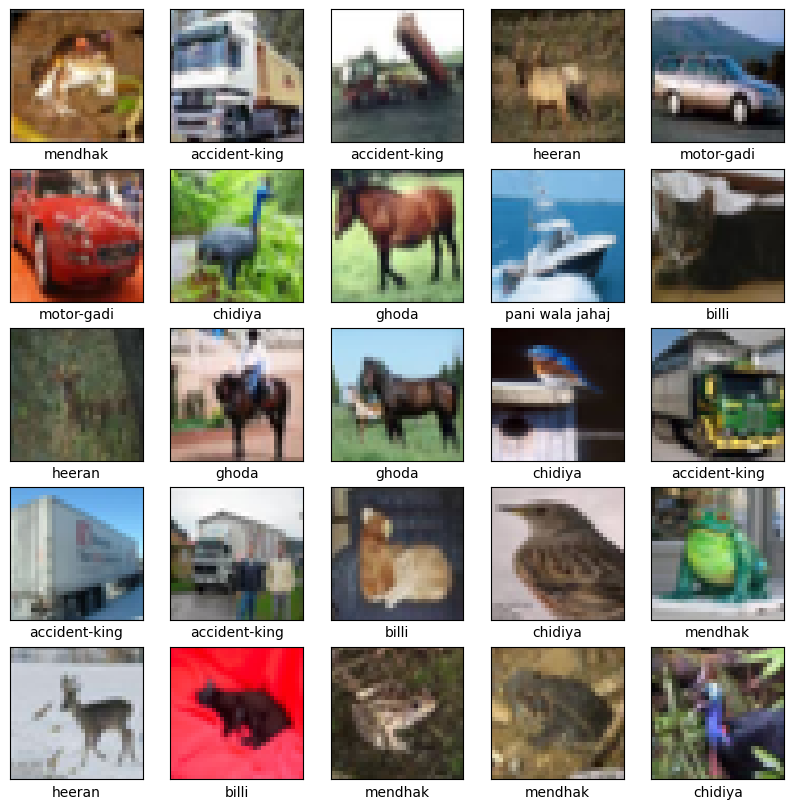

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR-10 labels are arrays, so you need to pick the first (and only) element
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

### 3. Define and Compile a Baseline CNN Model

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

### 4. Train the Model

In [ ]:
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.4416 - loss: 1.5343 - val_accuracy: 0.5480 - val_loss: 1.2786
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.5806 - loss: 1.1780 - val_accuracy: 0.6062 - val_loss: 1.1236
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6389 - loss: 1.0253 - val_accuracy: 0.6542 - val_loss: 0.9879
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6745 - loss: 0.9294 - val_accuracy: 0.6716 - val_loss: 0.9319
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6981 - loss: 0.8550 - val_accuracy: 0.6871 - val_loss: 0.9124
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.7236 - loss: 0.7842 - val_accuracy: 0.7016 - val_loss: 0.8625
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.7422 - loss: 0.7355 - val_accuracy: 0.7038 - val_loss: 0.8630
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7550 -

### 5. Evaluate the Model

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

### 6. Generate Classification Report and Confusion Matrix

### 7. Visualize Convolution and Pooling Outputs

In [ ]:
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(test_labels, predicted_labels, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(test_labels, predicted_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### 7. Visualize Convolution and Pooling Outputs

In [ ]:
# Select a random image from the test set for visualization
img_index = np.random.randint(0, len(test_images))
sample_image = test_images[img_index]
sample_label = test_labels[img_index][0]

print(f"Visualizing activations for image of class: {class_names[sample_label]}")

# Reshape the image to match the model's input shape (add batch dimension)
input_image = np.expand_dims(sample_image, axis=0)

# Define a list of layers to visualize (e.g., first few Conv2D and MaxPooling2D layers)
layer_names = ['conv2d', 'max_pooling2d', 'conv2d_1', 'max_pooling2d_1', 'conv2d_2']
outputs = [model.get_layer(name).output for name in layer_names]

# Create a Keras model that will output the activations from these layers
activation_model = models.Model(inputs=model.input, outputs=outputs)

# Get the activations for the sample image
activations = activation_model.predict(input_image)

plt.figure(figsize=(15, 8))
plt.suptitle(f"Activations for an image of {class_names[sample_label]}", fontsize=16)

# Display the original image
plt.subplot(len(layer_names) + 1, 1, 1)
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis('off')

# Plot activations for each layer
for i, (layer_activation, layer_name) in enumerate(zip(activations, layer_names)):
    # Number of features in the feature map
    n_features = layer_activation.shape[-1]
    # The activation is a 4D tensor (1, height, width, n_features)
    size = layer_activation.shape[1]

    # Display the activation maps (first 8 filters)
    n_cols = min(n_features, 8) # Display max 8 filters
    display_grid = np.zeros((size, n_cols * size))

    for col in range(n_cols):
        channel_image = layer_activation[0, :, :, col]
        # Post-process the feature to make it visually palatable
        channel_image -= channel_image.mean()
        channel_image /= channel_image.std()
        channel_image *= 64
        channel_image += 128
        channel_image = np.clip(channel_image, 0, 255).astype('uint8')
        display_grid[:, col * size : (col + 1) * size] = channel_image

    scale = 1. / size
    plt.subplot(len(layer_names) + 1, 1, i + 2)
    plt.title(f'{layer_name} Activations (First {n_cols} Filters)')
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers
import tensorflow as tf # Added this import for datasets.cifar10.load_data()

# Re-define test_images, test_labels, and class_names for robustness
# Load the CIFAR-10 dataset (ignoring train data as not needed here)
(_, _), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
# Normalize pixel values to be between 0 and 1
test_images = test_images / 255.0
# Define class names for CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Re-define the model for robustness in this cell
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

# Explicitly build the model to set its input shape
model.build(input_shape=(None, 32, 32, 3)) # None for batch size

# Compile the model (necessary if we were to train it, but here just for structure)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Note: The model needs to be trained before its weights can be used for activation visualization.
# For the purpose of *this specific cell* being self-contained, we are redefining the model
# with the same structure as the one previously trained. If you've reset the kernel and
# want to see activations of a *trained* model, you'd need to re-run the training step (cell 38b31bae)
# or load saved weights into this re-defined model.


# Select a random image from the test set for visualization
img_index = np.random.randint(0, len(test_images))
sample_image = test_images[img_index]
sample_label = test_labels[img_index][0]

print(f"Visualizing activations for image of class: {class_names[sample_label]}")

# Reshape the image to match the model's input shape (add batch dimension)
input_image = np.expand_dims(sample_image, axis=0)

# Define a list of layers to visualize (e.g., first few Conv2D and MaxPooling2D layers)
layer_names = ['conv2d_15', 'max_pooling2d_10', 'conv2d_16', 'max_pooling2d_11', 'conv2d_17']
outputs = [model.get_layer(name).output for name in layer_names]

# Create a Keras model that will output the activations from these layers
activation_model = models.Model(inputs=model.input, outputs=outputs)

# Get the activations for the sample image
activations = activation_model.predict(input_image)

plt.figure(figsize=(15, 8))
plt.suptitle(f"Activations for an image of {class_names[sample_label]}", fontsize=16)

# Display the original image
plt.subplot(len(layer_names) + 1, 1, 1)
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis('off')

# Plot activations for each layer
for i, (layer_activation, layer_name) in enumerate(zip(activations, layer_names)):
    # Number of features in the feature map
    n_features = layer_activation.shape[-1]
    # The activation is a 4D tensor (1, height, width, n_features)
    size = layer_activation.shape[1]

    # Display the activation maps (first 8 filters)
    n_cols = min(n_features, 8) # Display max 8 filters
    display_grid = np.zeros((size, n_cols * size))

    for col in range(n_cols):
        channel_image = layer_activation[0, :, :, col]
        # Post-process the feature to make it visually palatable
        channel_image -= channel_image.mean()
        channel_image /= channel_image.std()
        channel_image *= 64
        channel_image += 128
        channel_image = np.clip(channel_image, 0, 255).astype('uint8')
        display_grid[:, col * size : (col + 1) * size] = channel_image

    scale = 1. / size
    plt.subplot(len(layer_names) + 1, 1, i + 2)
    plt.title(f'{layer_name} Activations (First {n_cols} Filters)')
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()